In [1]:
#import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3


In [2]:
#1. import database --> data 

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
SELECT name 
FROM sqlite_master
WHERE type ='table'
"""

tables = pd.read_sql(sql_query,conn)

#create dataframe for each table 

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Create dataframe: df_{table_name}")

Create dataframe: df_db_customer
Create dataframe: df_db_subscription
Create dataframe: df_db_support


In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [6]:
# rename column - name  as customer name 
# drop columns interest and pincode 
# change data type of dob column
# data standardization of gender
# fix missing values country


In [7]:
# rename columns name in customer_name
df_db_customer.rename(columns={'name' : 'customer_name'},inplace=True)

In [8]:
# drop columns - interest and pincode 
# on the bases of index 
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
# on the bases of columns name 

df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [9]:
# change data type 

df_db_customer['dob']= pd.to_datetime(df_db_customer['dob'])

In [10]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [11]:
#replacing the values
df_db_customer['gender'].replace({'Men' : 'Male','Women' : 'Female'},inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15576\161336515.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men' : 'Male','Women' : 'Female'},inplace=True)


In [12]:
# fix missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [13]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [14]:
df_db_customer['country']= df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [16]:
df_db_subscription.info()
#cltv customer live time value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [17]:
# change data type of columns -- subscription_start_date , cancellation_date , renewal_date

In [18]:
# change multy_col date time in one 
date_col = ['subscription_start_date','cancellation_date','renewal_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [19]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [21]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [22]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [23]:
df_db_support.drop(columns=['col_1'],inplace=True)

# feacture engineering and data analysis

In [24]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [25]:
df_db_support.head(10)

,customerid,complaint_date,escalations,csat_score,comment
0,0003-MKNFE,2024-08-28,N,60,service issue
1,0003-MKNFE,2024-08-28,Y,10,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None
3,0013-MHZWF,2025-03-18,N,90,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None
5,0017-IUDMW,2024-04-10,Y,25,None
6,0019-EFAEP,2024-09-27,Y,30,None
7,0022-TCJCI,2024-09-13,Y,10,None
8,0022-TCJCI,2024-09-14,N,90,received refund


In [26]:
#removing the duplicate
df_db_support.drop_duplicates(subset=['customerid'],keep='last',inplace=True)

In [27]:
# joinning the table 

df = (df_db_subscription.merge(df_db_customer,on= 'customerid',how= 'left').merge(df_db_support,on='customerid',how= 'left'))


In [28]:
df.shape

(21, 21)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
 12  customer_name            21 non-null  

In [30]:
df.to_csv('exported_chrun_data.csv',index=False)

In [31]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment'],
      dtype='object')

data analysis

In [32]:
churn_rate = df['churn_flag'].mean()*100
print("churn rate = ",round(churn_rate,2),"%")

churn rate =  28.57 %


In [33]:
# retenion rate 
retention_rate = 100-churn_rate
print("retention rate = ",round(retention_rate,2),"%")

retention rate =  71.43 %


In [34]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,demaned refund
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,None


In [35]:
# chrun by plan type 
churn_by_plan =(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [36]:
churn_by_conttype = df.groupby(['plan_type','contract_type'])['churn_flag'].mean()*100
print(churn_by_conttype)

plan_type  contract_type
Basic      Annual            0.000000
           Monthly          75.000000
Premium    Annual           14.285714
Standard   Annual            0.000000
           Monthly          40.000000
Name: churn_flag, dtype: float64


In [37]:
retention_rate_by_pc = 100-(df.groupby(['plan_type','contract_type'])['churn_flag'].mean()*100)
print(retention_rate_by_pc)

plan_type  contract_type
Basic      Annual           100.000000
           Monthly           25.000000
Premium    Annual            85.714286
Standard   Annual           100.000000
           Monthly           60.000000
Name: churn_flag, dtype: float64


In [38]:

state_revenue = df.groupby('state')['monthly_charges'].sum().reset_index(name="total_monthly_charge")
print(state_revenue)

           state  total_monthly_charge
0          Delhi                 52.96
1      Karnataka                 20.98
2      Kathmandu                 20.98
3    Maharashtra                 50.97
4      Meghalaya                 42.97
5       Nagaland                 22.99
6      Rajasthan                 36.98
7      Telangana                 30.98
8  Uttar Pradesh                115.98


In [39]:
# total sales , churn_rate ,total_user by state 
state_churn_revenue = df.groupby('state').agg( total_sales = ('monthly_charges','sum'),churn_rate =(('churn_flag',lambda x: x.mean() * 100)),total_user = ('customerid','count'))
print(state_churn_revenue)

               total_sales  churn_rate  total_user
state                                             
Delhi                52.96   25.000000           4
Karnataka            20.98  100.000000           2
Kathmandu            20.98    0.000000           2
Maharashtra          50.97    0.000000           3
Meghalaya            42.97   66.666667           3
Nagaland             22.99    0.000000           1
Rajasthan            36.98    0.000000           2
Telangana            30.98   50.000000           2
Uttar Pradesh       115.98    0.000000           2


In [40]:
# churn rate basis of subscription_type
churn_subscription_type = df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_subscription_type)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [41]:
# average revenue per user 
avg_rev_peruser = round(((df['monthly_charges'].sum())/ df['customerid'].count()),2)

print(avg_rev_peruser)

18.85


In [42]:
# avg customer tenure 
# count of days users has used our services 
today = pd.Timestamp.today()
today

Timestamp('2026-09-18 18:38:01.171723')

In [43]:
df['tenure_day'] = np.where(
    df['cancellation_date'].notna(),(df['cancellation_date']-df['subscription_start_date']).dt.days,(today-
df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_day'].mean().round()

print(avg_tenure)

1542.0


In [44]:
# revenue at risk 

revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue at risk Rs. 'k' = ",revenue_at_risk)

revenue at risk Rs. 'k' =  73.94


In [45]:
# esclation rate
esclation_rate = (df['escalations']=='Y').mean()*100
print(esclation_rate)

19.047619047619047


In [46]:
#avg complaint per user
avg_complaint_per_user = ((df['escalations']).count()/df['customerid'].nunique())
print("average complaint per user : ", round(avg_complaint_per_user*100,2),"%")

average complaint per user :  33.33 %


In [47]:
df['escalations'] = np.where(df['escalations']=='Y',1,0)

In [48]:
# correlation esclation vs churn 
corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ",round(correlation,2))

Correlation between esclation vs churn is =  0.77


In [49]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [50]:
# churn risk - create a column using existing col 
df['churn_risk'] = np.select([
    (df['churn_score']<50),
    (df['churn_score']<70),
    (df['churn_score']>=70)],['low','med','high'],default ='unknown')

In [51]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,comment,tenure_day,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2013.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,demaned refund,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1398.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2688.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,None,419.0,high


visualization using matplotlib

In [52]:
df_visual = df.copy()


In [53]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'tenure_day',
       'churn_risk'],
      dtype='object')

In [54]:
# monthly churn trend (time series kpi)

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

<function matplotlib.pyplot.show(close=None, block=None)>

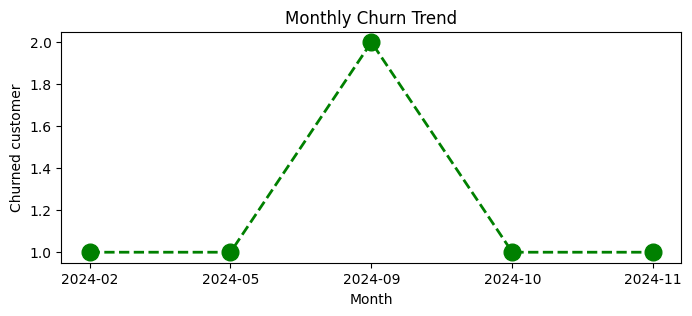

In [55]:
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values, color = 'green', marker = 'o' , linestyle = 'dashed' , linewidth = 2 , markersize = 12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned customer')
plt.show

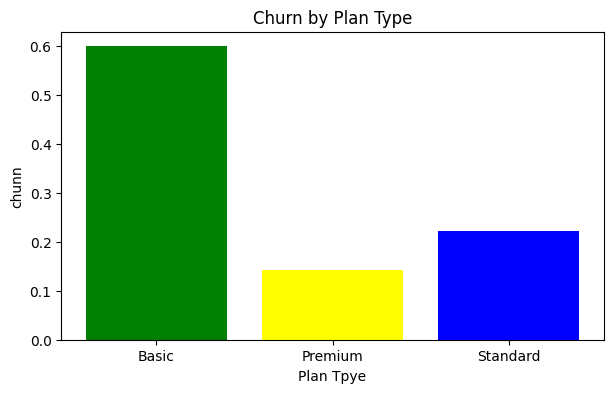

In [56]:
# churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))
colors = ['green','yellow','blue']
plt.bar(churn_plan.index.astype(str),churn_plan.values,color =colors)
plt.title('Churn by Plan Type')
plt.xlabel('Plan Tpye')
plt.ylabel('chunn')
plt.show()

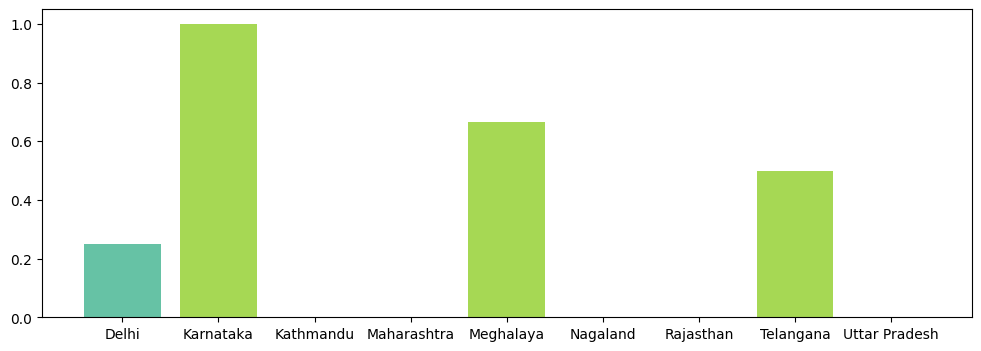

In [57]:
#churn by states

churn_state = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_state.index,churn_state.values, color = colors)
plt.show()

In [58]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'comment', 'tenure_day',
       'churn_risk', 'cancellation_month'],
      dtype='object')

Text(0.5, 1.0, 'gender wise monthly revenue')

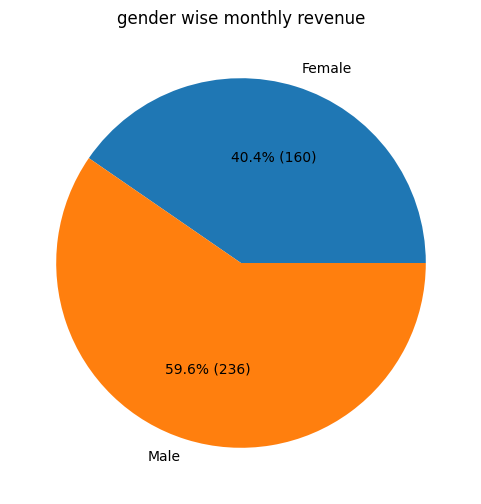

In [59]:
churn_gender = df_visual.groupby('gender')['monthly_charges'].sum()
plt.figure(figsize=(6,6))
plt.pie(churn_gender.values,labels=churn_gender.index,autopct=lambda p: f'{p:.1f}% ({p * churn_gender.sum() / 100:.0f})'
)
plt.title('gender wise monthly revenue')

In [60]:
#visulaization using seaborn

In [61]:
#encoding - convert str to numberic so that we can find corr between feactures

df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1
5,Standard,Annual,22,0,low,0
6,Basic,Monthly,79,1,high,0
7,Premium,Annual,5,0,low,0
8,Standard,Monthly,34,0,low,0
9,Basic,Annual,41,0,low,0


In [62]:
import warnings

warnings.filterwarnings("ignore")

In [63]:
## this is incorrect way of the encoding

df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [64]:
df_encoded.head(20)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1
5,2,0,22,0,1,0
6,0,1,79,1,0,0
7,1,0,5,0,1,0
8,2,1,34,0,1,0
9,0,0,41,0,1,0


<Axes: >

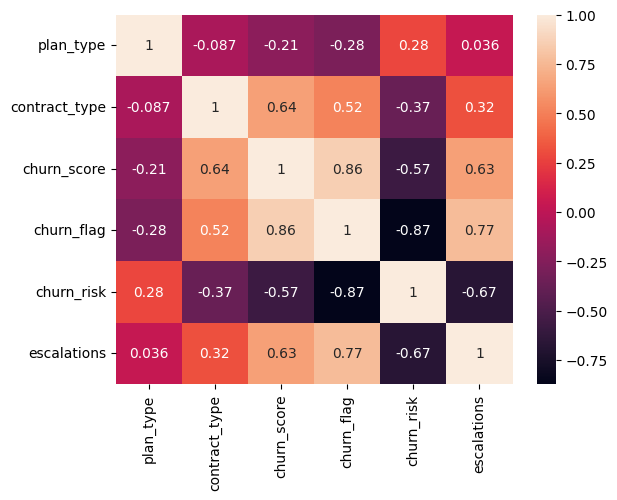

In [65]:
#heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)

In [66]:
#correct method of encoding - basex on priority

df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mappings = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

<Axes: >

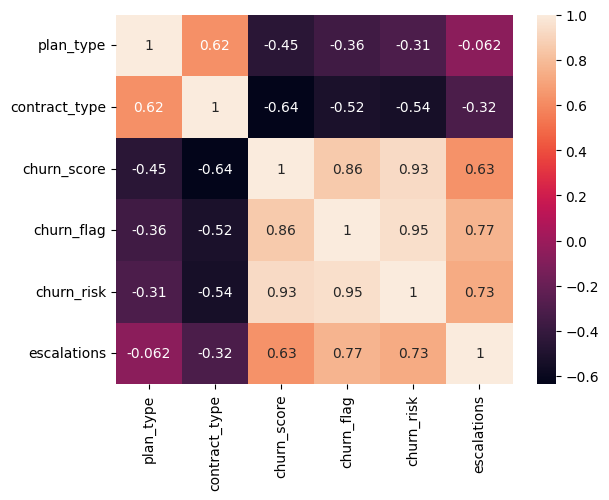

In [67]:
sns.heatmap(df_encoded.corr(),annot=True)

#pair plot
## this is use to show the multiple chart and show the relation b/w different kpis

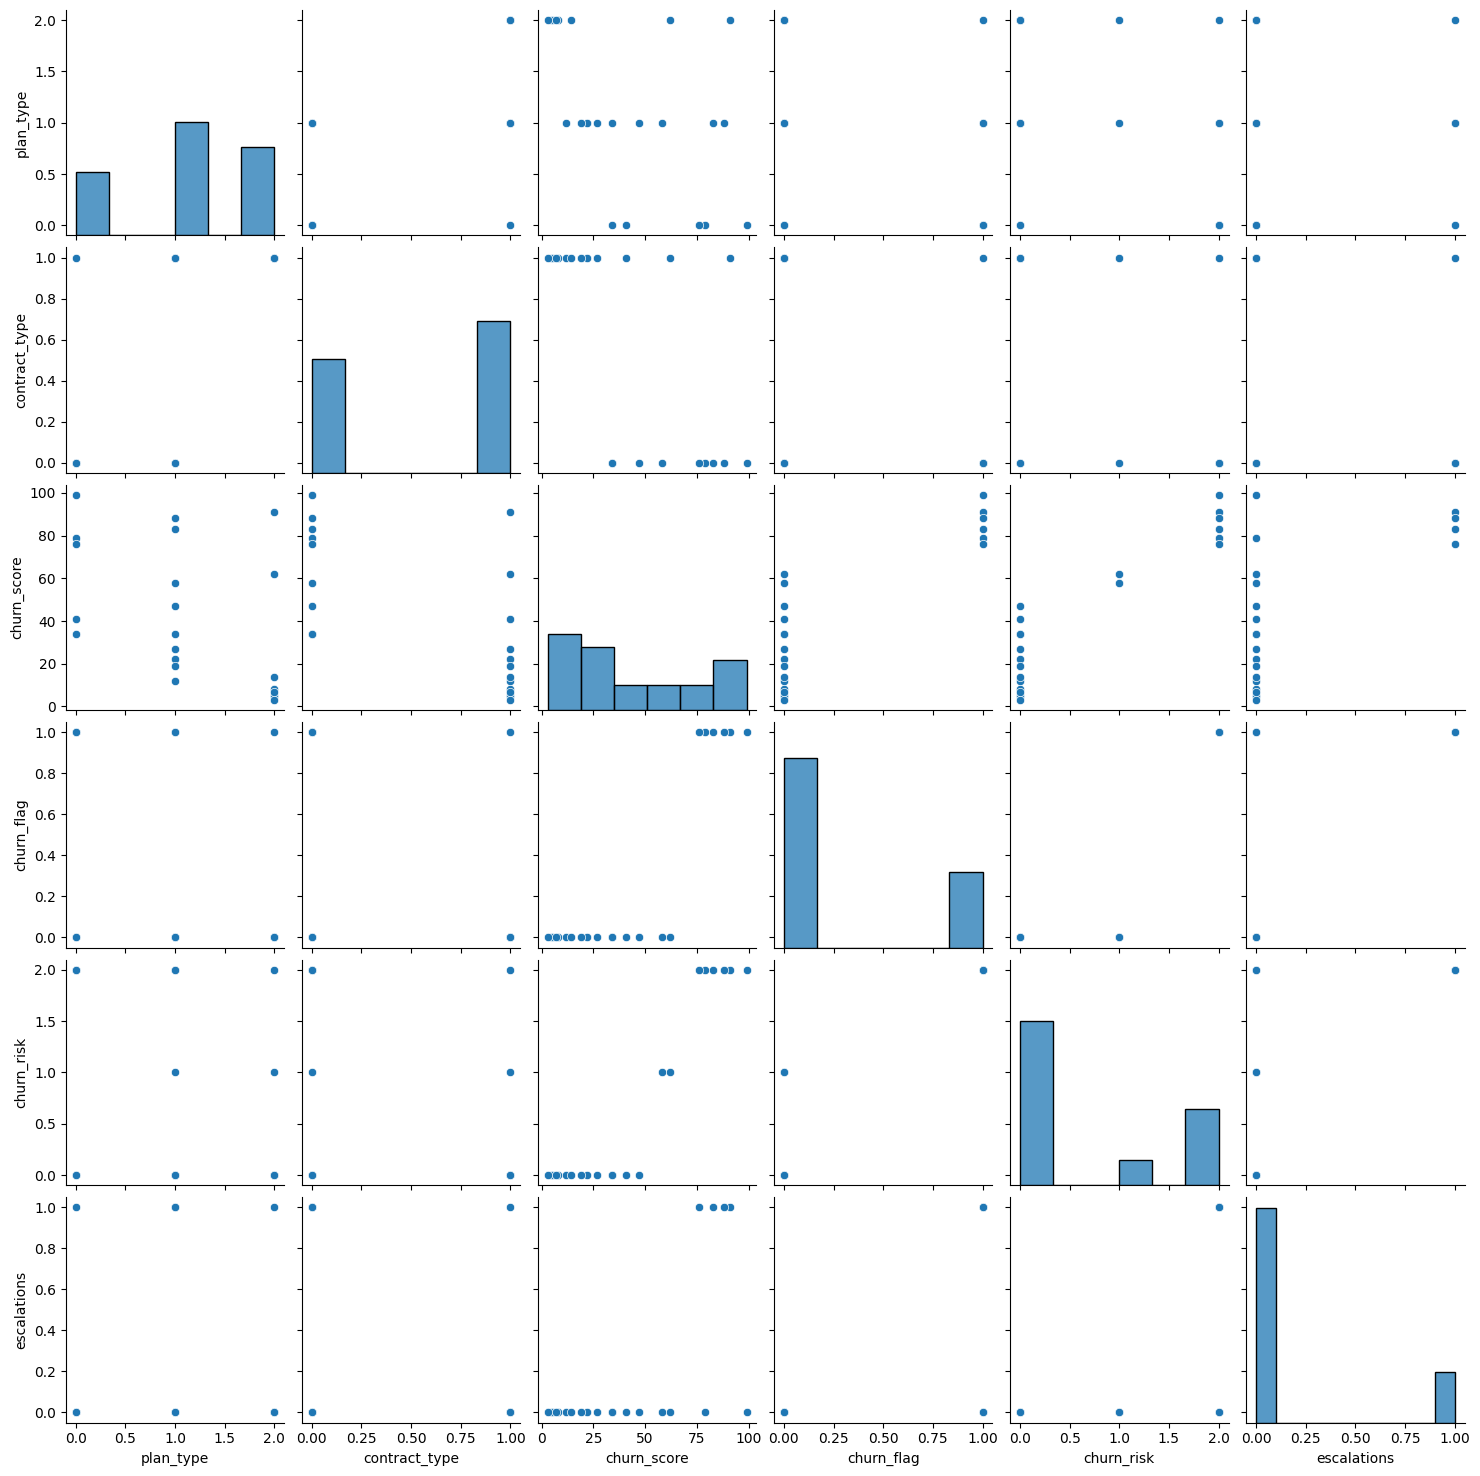

In [68]:
sns.pairplot(df_encoded)


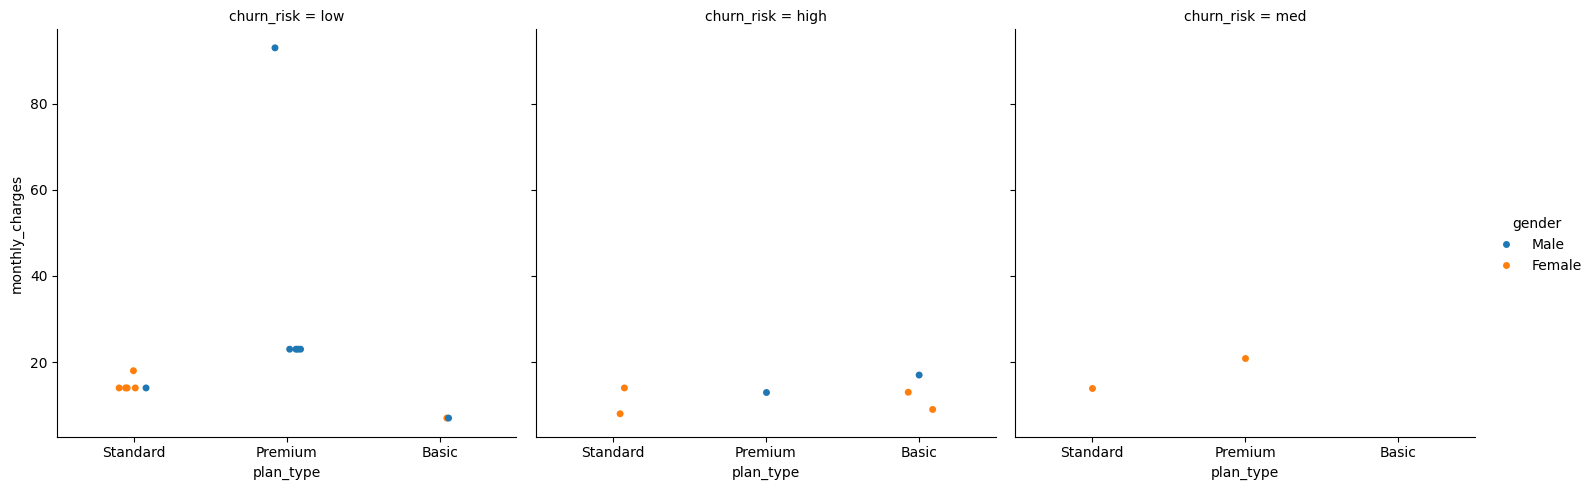

In [69]:
#catplt/facegrid plot 
# this is multi dim comparison
sns.catplot(data = df_visual,x = 'plan_type' , y = 'monthly_charges',hue = 'gender',col = 'churn_risk')

pivot table

In [70]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
).reset_index() # reset_index to make the table look like the dataframe

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [71]:
pd.pivot_table(
    df_visual,
    values = ['monthly_charges','customerid','churn_flag'],
    index = 'plan_type',
    aggfunc = {'monthly_charges' :'sum','customerid' : 'count' ,'churn_flag':'mean'}
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [72]:
#working with sql in python (pandas)

In [73]:
#create db in sql

In [74]:
conn = sqlite3.connect('test_database.sqlite')

# table details 
conn.execute("CREATE TABLE user(first_name text , country text, budget integer)")

# commit and save 
conn.commit()

OperationalError: table user already exists

In [ ]:
#insert data 
cursor = conn.cursor()

cursor.execute(
    """insert into user values('madhav','indian',5000)"""
)

conn.commit()

In [ ]:
#check inserted data in tableabs 
conn = sqlite3.connect('test_database.sqlite')
query = """select * from user"""

df_result = pd.read_sql(query,conn)
df_result.head()

In [ ]:
#aggregation
query = """
select country , sum(budget)as total_budget
from user
group by country
"""

df_agg = pd.read_sql(query,conn)
df_agg


In [ ]:
#always close the conn with db once the task is over
conn.close()
print('connection closed successfully')